Game   Sl.    Random   Head   Cumulative      Difference
No.    No.    Number   or Tail Heads    Tails  
-----------------------------------------------------------------
1      1      6        T      0        1       1
       2      3        H      1        1       0
       3      4        H      2        1       1
       4      0        H      3        1       2
       5      1        H      4        1       3
                                                   Win Re. 3
-----------------------------------------------------------------
2      1      3        H      1        0       1
       2      0        H      2        0       2
       3      5        T      2        1       1
       4      1        H      3        1       2
       5      8        T      3        2       1
       6      1        H      4        2       2
       7      7        T      4        3       1
       8      3        H      5        3       2
       9      5        T      5        4       1
       10     6 

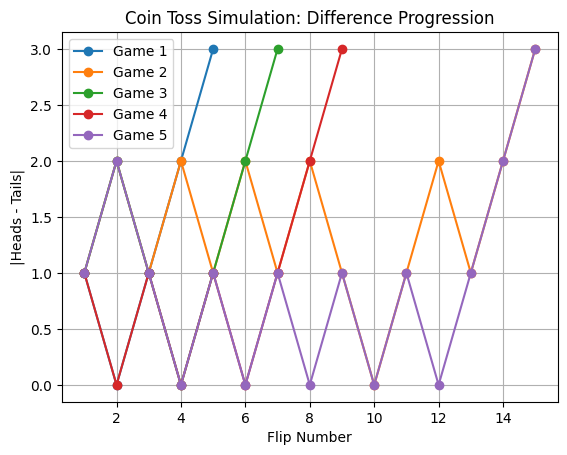

In [1]:
import random
import matplotlib.pyplot as plt

def simulate_table_format(num_games):
    # Header
    print(f"{'Game':<6} {'Sl.':<6} {'Random':<8} {'Head':<6} {'Cumulative':<15} {'Difference'}")
    print(f"{'No.':<6} {'No.':<6} {'Number':<8} {'or Tail':<6} {'Heads':<8} {'Tails':<7}")
    print("-" * 65)

    # Store plot data
    all_steps = []
    all_diffs = []

    for g_no in range(1, num_games + 1):
        heads = 0
        tails = 0
        sl_no = 1

        steps = []
        diffs = []

        while abs(heads - tails) < 3:
            # Generate random digit (0–9)
            rand_num = random.randint(0, 9)

            # 0–4 → Head, 5–9 → Tail
            if rand_num <= 4:
                result = 'H'
                heads += 1
            else:
                result = 'T'
                tails += 1

            diff = abs(heads - tails)

            steps.append(sl_no)
            diffs.append(diff)

            g_display = g_no if sl_no == 1 else ""

            print(f"{g_display:<6} {sl_no:<6} {rand_num:<8} {result:<6} {heads:<8} {tails:<7} {diff}")

            sl_no += 1

        # Cost and profit calculation
        cost = sl_no - 1      # 1 taka per flip
        winnings = 8          # reward when difference reaches 3
        net = winnings - cost

        if net >= 0:
            print(f"{'':<50} Win Re. {net}")
        else:
            print(f"{'':<50} Lose Re. {abs(net)}")
        print("-" * 65)

        all_steps.append(steps)
        all_diffs.append(diffs)

    # ================== PLOT ==================
    plt.figure()

    for i in range(num_games):
        plt.plot(all_steps[i], all_diffs[i], marker='o', label=f"Game {i+1}")

    plt.xlabel("Flip Number")
    plt.ylabel("|Heads - Tails|")
    plt.title("Coin Toss Simulation: Difference Progression")
    plt.legend()
    plt.grid(True)
    plt.show()


# Run simulation (example: 5 games)
simulate_table_format(5)
